In [27]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q monai-weekly nibabel simpleitk torchio scikit-image tqdm matplotlib tensorboard rich ml-collections

from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted at /content/drive


In [28]:
import os, json, torch, time, math
import matplotlib.pyplot as plt
from monai.data import CacheDataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, RandSpatialCropd, RandFlipd, RandAffined,
    RandGaussianNoised, RandAdjustContrastd, EnsureTyped, SpatialPadd
)
from monai.networks.nets import SegResNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
from monai.data.utils import decollate_batch

BASE = "/content/drive/MyDrive/faks/7SEMESTAR/MANU/MOTUM-v.2.2"
DATASET_JSON = f"{BASE}/data/dataset.json"
SPLITS_JSON  = f"{BASE}/data/splits/splits_5fold.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(DATASET_JSON) as f:
    DS = json.load(f)
with open(SPLITS_JSON) as f:
    SPLITS = json.load(f)


In [29]:
def build_lists(fold: int, setup: str):
    all_items = DS["training"]
    fold_info = [s for s in SPLITS if s["fold"] == fold][0]
    tr_ids, va_ids = set(fold_info["train"]), set(fold_info["val"])

    def sel_channels(imgs):
      if setup == "t1ce":
          return [{"image": imgs["t1ce"]}]
      elif setup == "t1ce_flair":
          return [{"image": imgs["t1ce"]}, {"image": imgs["flair"]}]
      elif setup == "all4":
          return [{"image": imgs[m]} for m in ["flair", "t1", "t1ce", "t2"]]
      else:
          raise ValueError("Unknown setup")



    train_list, val_list = [], []
    for it in all_items:
        sample = {
            "pid": it["patient_id"],
            "label_ce": it["labels"]["ce_core"],
            "label_fl": it["labels"]["flair_abn"],
        }
        sample.update(sel_channels(it["images"]))
        (train_list if it["patient_id"] in tr_ids else val_list).append(sample)
    return train_list, val_list


def get_transforms(patch_size=(128,128,128)):
    common = [
        LoadImaged(keys=["im","label_ce","label_fl"]),
        EnsureChannelFirstd(keys=["im","label_ce","label_fl"]),
        Orientationd(keys=["im","label_ce","label_fl"], axcodes="RAS"),
        Spacingd(keys=["im","label_ce","label_fl"], pixdim=(1,1,1),
                 mode=("bilinear","nearest","nearest")),
        NormalizeIntensityd(keys=["im"], nonzero=True, channel_wise=True),
        EnsureTyped(keys=["im","label_ce","label_fl"]),
    ]
    train_aug = [
        SpatialPadd(keys=["im","label_ce","label_fl"], spatial_size=patch_size),
        RandSpatialCropd(keys=["im","label_ce","label_fl"], roi_size=patch_size, random_size=False),
        RandFlipd(keys=["im","label_ce","label_fl"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["im","label_ce","label_fl"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["im","label_ce","label_fl"], prob=0.5, spatial_axis=2),
        RandAffined(keys=["im","label_ce","label_fl"], prob=0.2,
                    rotate_range=(0.1,0.1,0.1), scale_range=(0.1,0.1,0.1),
                    mode=("bilinear","nearest","nearest")),
        RandAdjustContrastd(keys=["im"], prob=0.15, gamma=(0.7,1.5)),
        RandGaussianNoised(keys=["im"], prob=0.15, mean=0.0, std=0.01),
        EnsureTyped(keys=["im","label_ce","label_fl"]),
    ]
    val_aug = [
        SpatialPadd(keys=["im","label_ce","label_fl"], spatial_size=patch_size),
        RandSpatialCropd(keys=["im","label_ce","label_fl"], roi_size=patch_size, random_size=False),
        EnsureTyped(keys=["im","label_ce","label_fl"]),
    ]
    return Compose(common + train_aug), Compose(common + val_aug)


def merge_labels_collate(batch):
    from torch.utils.data.dataloader import default_collate
    b = default_collate(batch)
    label = torch.zeros_like(b["label_ce"], dtype=torch.long).squeeze(1)
    fl = b["label_fl"].squeeze(1).long()
    ce = b["label_ce"].squeeze(1).long()
    label = label + (fl>0).long()*1
    label = torch.where(ce>0, torch.tensor(2, device=label.device), label)
    b["label"] = label
    b.pop("label_ce", None)
    b.pop("label_fl", None)
    return b


def make_dataloaders(fold=0, setup="t1ce", patch_size=(128,128,128),
                     batch_size=1, num_workers=2, cache_rate=0.0):
    tr, va = build_lists(fold, setup)
    tr_tf, va_tf = get_transforms(patch_size)
    tr_ds = CacheDataset(tr, tr_tf, cache_rate, num_workers)
    va_ds = CacheDataset(va, va_tf, cache_rate, num_workers)
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                           num_workers=num_workers, pin_memory=True,
                           collate_fn=merge_labels_collate)
    va_loader = DataLoader(va_ds, batch_size=1, shuffle=False,
                           num_workers=num_workers, pin_memory=True,
                           collate_fn=merge_labels_collate)
    return tr_loader, va_loader


In [30]:
import json, re

BASE = "/content/drive/MyDrive/faks/7SEMESTAR/MANU/MOTUM-v.2.2"
dataset_path = f"{BASE}/data/dataset.json"

with open(dataset_path, "r") as f:
    data = json.load(f)

def fix_path(p):
    p = p.replace("G:\\My Drive\\", "/content/drive/MyDrive/")
    p = p.replace("\\", "/")
    return p

for item in data["training"]:
    for k, v in item["images"].items():
        item["images"][k] = fix_path(v)
    for k, v in item["labels"].items():
        item["labels"][k] = fix_path(v)

with open(dataset_path, "w") as f:
    json.dump(data, f, indent=2)


In [31]:
!pip install -q monai-weekly nibabel simpleitk torchio scikit-image tqdm matplotlib

import os, time, torch
from monai.networks.nets import DynUNet
from monai.data import CacheDataset, DataLoader
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, EnsureTyped, RandSpatialCropd,
    RandFlipd, RandAffined, RandAdjustContrastd, RandGaussianNoised, SpatialPadd
)
from monai.inferers import sliding_window_inference
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


DATA_JSON = "/content/drive/MyDrive/faks/7SEMESTAR/MANU/MOTUM-v.2.2/data/dataset.json"
DATA_DIR = "/content/drive/MyDrive/faks/7SEMESTAR/MANU/MOTUM-v.2.2/images"

def build_lists(fold: int, setup: str):
    all_items = DS["training"]
    fold_info = [s for s in SPLITS if s["fold"] == fold][0]
    tr_ids, va_ids = set(fold_info["train"]), set(fold_info["val"])

    def sel_channels(imgs):
        if setup == "t1ce":
            return {"im": [imgs["t1ce"]]}
        elif setup == "t1ce_flair":
            return {"im": [imgs["t1ce"], imgs["flair"]]}
        elif setup == "all4":
            return {"im": [imgs[m] for m in ["flair", "t1", "t1ce", "t2"]]}
        else:
            raise ValueError("Unknown setup")

    train_list, val_list = [], []
    for it in all_items:
        sample = {
            "pid": it["patient_id"],
            "label_ce": it["labels"]["ce_core"],
            "label_fl": it["labels"]["flair_abn"],
        }
        sample.update(sel_channels(it["images"]))
        (train_list if it["patient_id"] in tr_ids else val_list).append(sample)
    return train_list, val_list


def make_dataloaders(fold=0, setup="t1ce_flair", patch_size=(160,160,160),
                     batch_size=1, num_workers=2, cache_rate=0.0):
    tr, va = build_lists(fold, setup)
    tr_tf, va_tf = get_transforms(patch_size)
    tr_ds = CacheDataset(tr, tr_tf, cache_rate, num_workers)
    va_ds = CacheDataset(va, va_tf, cache_rate, num_workers)
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                           num_workers=num_workers, pin_memory=True,
                           collate_fn=merge_labels_collate)
    va_loader = DataLoader(va_ds, batch_size=1, shuffle=False,
                           num_workers=num_workers, pin_memory=True,
                           collate_fn=merge_labels_collate)
    return tr_loader, va_loader


def get_transforms(patch_size=(160,160,160)):
    common = [
        LoadImaged(keys=["im", "label_ce", "label_fl"]),
        EnsureChannelFirstd(keys=["im", "label_ce", "label_fl"]),
        Orientationd(keys=["im", "label_ce", "label_fl"], axcodes="RAS"),
        Spacingd(keys=["im", "label_ce", "label_fl"], pixdim=(1,1,1),
                 mode=("bilinear","nearest","nearest")),
        NormalizeIntensityd(keys=["im"], nonzero=True, channel_wise=True),
        EnsureTyped(keys=["im", "label_ce", "label_fl"]),
    ]
    train_aug = [
        SpatialPadd(keys=["im", "label_ce", "label_fl"], spatial_size=patch_size),
        RandSpatialCropd(keys=["im", "label_ce", "label_fl"], roi_size=patch_size, random_size=False),
        RandFlipd(keys=["im", "label_ce", "label_fl"], prob=0.5, spatial_axis=[0,1,2]),
        RandAffined(keys=["im", "label_ce", "label_fl"], prob=0.2,
                    rotate_range=(0.1,0.1,0.1), scale_range=(0.1,0.1,0.1),
                    mode=("bilinear","nearest","nearest")),
        RandAdjustContrastd(keys=["im"], prob=0.15, gamma=(0.7,1.5)),
        RandGaussianNoised(keys=["im"], prob=0.15, mean=0.0, std=0.01),
        EnsureTyped(keys=["im", "label_ce", "label_fl"]),
    ]
    val_aug = [
        SpatialPadd(keys=["im", "label_ce", "label_fl"], spatial_size=patch_size),
        RandSpatialCropd(keys=["im", "label_ce", "label_fl"], roi_size=patch_size, random_size=False),
        EnsureTyped(keys=["im", "label_ce", "label_fl"]),
    ]
    return Compose(common + train_aug), Compose(common + val_aug)


def merge_labels_collate(batch):
    from torch.utils.data.dataloader import default_collate
    b = default_collate(batch)
    label = torch.zeros_like(b["label_ce"], dtype=torch.long).squeeze(1)
    fl = b["label_fl"].squeeze(1).long()
    ce = b["label_ce"].squeeze(1).long()
    label = label + (fl > 0).long() * 1
    label = torch.where(ce > 0, torch.tensor(2, device=label.device), label)
    b["label"] = label
    b.pop("label_ce", None)
    b.pop("label_fl", None)
    return b

def make_model_dynunet(in_channels, out_channels=3, base_filters=32):
    return DynUNet(
        spatial_dims=3,
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=[3,3,3,3,3,3],
        strides=[1,2,2,2,2,2],
        upsample_kernel_size=[2,2,2,2,2],
        filters=[base_filters, base_filters*2, base_filters*4, base_filters*8, base_filters*16, base_filters*32],
        dropout=0.1,
        norm_name="instance",
        act_name=("leakyrelu", {"inplace": True, "negative_slope": 0.01}),
        deep_supervision=False
    ).to(DEVICE)


@torch.no_grad()
def validate(model, loader, roi_size=(160,160,160)):
    model.eval()
    dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
    total_time = 0.0

    for batch in loader:
        imgs = batch["im"].to(DEVICE)
        labels = batch["label"].to(DEVICE).long()

        if imgs.ndim == 6:
            imgs = imgs.squeeze(2)

        labels = torch.nn.functional.one_hot(labels, num_classes=3)
        labels = labels.permute(0, 4, 1, 2, 3).float()

        t0 = time.time()
        preds = sliding_window_inference(imgs, roi_size=roi_size, sw_batch_size=1, predictor=model)
        total_time += time.time() - t0
        dice_metric(y_pred=preds, y=labels)

    dice = dice_metric.aggregate().item()
    dice_metric.reset()
    return dice, total_time / max(1, len(loader))


def make_optim(model, lr=1e-4, wd=1e-5):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)


def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    for b in loader:
        imgs = b["im"].to(DEVICE)
        lbl = b["label"].to(DEVICE).long()

        # [B, D, H, W] → [B, 3, D, H, W]
        lbl = torch.nn.functional.one_hot(lbl, num_classes=3)
        lbl = lbl.permute(0, 4, 1, 2, 3).float()

        opt.zero_grad()
        out = model(imgs)
        loss = loss_fn(out, lbl)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    return total_loss / max(1, len(loader))


Device: cuda


In [32]:
EPOCHS = 100
PATCH = (160, 160, 160)
BATCH = 1
SETUP = "t1ce_flair"
IN_CHANNELS = 2
LR = 1e-4

tr, va = make_dataloaders(fold=0, setup=SETUP, patch_size=PATCH, batch_size=BATCH)

model = make_model_dynunet(IN_CHANNELS, out_channels=3)
loss_fn = DiceCELoss(sigmoid=False, softmax=True, include_background=True, to_onehot_y=False)

opt = make_optim(model, lr=LR)

train_losses, val_dices = [], []
best_dice = 0.0

print(f"setup={SETUP} | lr={LR} | epochs={EPOCHS}")
print("----------------------------------------------------------")

for ep in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, tr, opt, loss_fn)
    val_dice, val_time = validate(model, va, roi_size=PATCH)

    train_losses.append(tr_loss)
    val_dices.append(val_dice)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), f"best_dynunet_{SETUP}.pth")

    print(f"Epoch {ep:03d}/{EPOCHS} | Train Loss={tr_loss:.4f} | Val Dice={val_dice:.4f} | Time/sample={val_time:.2f}s")

print("----------------------------------------------------------")
print(f"Best Dice: {best_dice:.4f}")


setup=t1ce_flair | lr=0.0001 | epochs=100
----------------------------------------------------------
Epoch 001/100 | Train Loss=1.1859 | Val Dice=0.0283 | Time/sample=0.01s
Epoch 002/100 | Train Loss=0.9733 | Val Dice=0.0292 | Time/sample=0.01s
Epoch 003/100 | Train Loss=0.8934 | Val Dice=0.0282 | Time/sample=0.01s
Epoch 004/100 | Train Loss=0.8481 | Val Dice=0.0304 | Time/sample=0.01s
Epoch 005/100 | Train Loss=0.8077 | Val Dice=0.0288 | Time/sample=0.01s
Epoch 006/100 | Train Loss=0.7809 | Val Dice=0.0294 | Time/sample=0.01s
Epoch 007/100 | Train Loss=0.7587 | Val Dice=0.0292 | Time/sample=0.01s
Epoch 008/100 | Train Loss=0.7364 | Val Dice=0.0295 | Time/sample=0.01s
Epoch 009/100 | Train Loss=0.7129 | Val Dice=0.0281 | Time/sample=0.01s
Epoch 010/100 | Train Loss=0.6969 | Val Dice=0.0277 | Time/sample=0.01s
Epoch 011/100 | Train Loss=0.6831 | Val Dice=0.0283 | Time/sample=0.01s
Epoch 012/100 | Train Loss=0.6653 | Val Dice=0.0289 | Time/sample=0.01s
Epoch 013/100 | Train Loss=0.6457 |

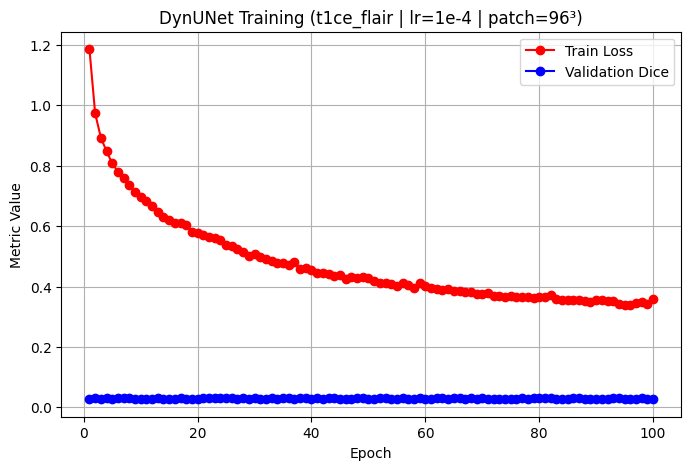

In [33]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, '-o', color='red', label='Train Loss')
plt.plot(range(1, len(val_dices)+1), val_dices, '-o', color='blue', label='Validation Dice')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('DynUNet Training (t1ce_flair | lr=1e-4 | patch=96³)')
plt.legend()
plt.grid(True)
plt.show()
